---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---

---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 3 : CNN FROM SCRATCH

---


---

## Plan du notebook - Partie 3 : CNN from scratch

| Cellule | Section | Contenu |
|---------|---------|---------|
| 1-3 | — | Header, principes, titre |
| 4 | — | Plan du notebook |
| 5-6 | — | Objectif + consignes, hyperparametres |
| 7-10 | Config | Imports, versions, seed, constantes |
| 11 | Modele | Fonction train_model |
| 12 | Modele | Preprocessing CNN (sans + avec aug) |
| 13 | Modele | Creation CNN + Q3.3 parametres |
| 14 | Exp 1 | Entrainement sans aug 40ep |
| 15 | Exp 1 | Courbes + gap Q3.1 |
| 16 | Exp 1 | Test set sans aug |
| 17 | Exp 1 | Matrice + report + tableau texte |
| 18 | Exp 1 | BONUS filtres appris |
| 19 | Exp 1 | Analyse resultats sans aug |
| 20 | Exp 2 | Entrainement avec aug 40ep |
| 21 | Exp 2 | Courbes avec aug |
| 22 | Exp 2 | Test set avec aug |
| 23 | Exp 2 | Matrice + report avec aug |
| 24 | Exp 2 | Tableau comparatif sans vs avec |
| 25 | Analyse | Analyse comparative |
| 26 | Questions | Q3.1 gap + Q3.2 augmentations + Q3.3 parametres |
| 27 | Bonus | Demarche iterative |
| 28 | Bonus | Tableau iterations |
| 29 | Bonus v1 | Titre v1 |
| 30 | Bonus v1 | Preprocessing v1 |
| 31 | Bonus v1 | Entrainement v1 40ep |
| 32 | Bonus v1 | Courbes v1 |
| 33 | Bonus v1 | Test + matrice v1 |
| 34 | Bonus v2 | Titre v2 |
| 35 | Bonus v2 | Preprocessing v2 |
| 36 | Bonus v2 | Entrainement v2 50ep |
| 37 | Bonus v2 | Courbes v2 |
| 38 | Bonus v2 | Test + matrice v2 |
| 39 | Bonus v3 | Titre v3 |
| 40 | Bonus v3 | Preprocessing v3 50ep |
| 41 | Bonus v3 | Entrainement v3 50ep |
| 42 | Bonus v3 | Courbes v3 50ep |
| 43 | Bonus v3 | Test v3 50ep |
| 44 | Bonus v3 | Entrainement v3 70ep |
| 45 | Bonus v3 | Courbes v3 70ep |
| 46 | Bonus v3 | Test + matrice v3 70ep |
| 47 | Bonus | Tableau comparatif toutes iterations |
| 48 | Sauvegarde | Modeles + historiques + predictions |
| 49 | Bilan | Bilan + analyses cles + limites methodologiques |
| 50 | — | Temps total |

---


---

### Objectif

Construire un CNN pour dépasser les limites du MLP. Le MLP de la partie 2 plafonnait à 68% car il traitait chaque pixel indépendamment. Le CNN va balayer l'image avec des filtres qui détectent les textures, les contours et les formes.

### Progression du projet
- **Partie 2 (MLP)** : 68.02% test accuracy
- **Partie 3 (CNN)** : exploiter la structure spatiale des images

### Consignes du sujet
- Architecture : ≥ 3 blocs convolutifs + batch normalization + dropout
- Data augmentation justifiée
- Seuil : ≥ 75% test accuracy
- Comparer avec vs sans augmentation (même modèle, mêmes hyperparamètres, 40 époques)
- **Q3.1** : Sans augmentation, 40 époques, à quelle époque le gap train/val accuracy dépasse 15 points ?
- **Q3.2** : Une augmentation qui exploite l'absence d'orientation canonique en histologie + une augmentation nuisible
- **Q3.3** : Nombre total de paramètres + calcul manuel de la 1ère couche conv

---




---

### Choix d'architecture et d'hyperparamètres CNN

**Lien avec le Lab 2 :**
- Architecture inspirée des exercices 1 à 3 du Lab 2 (VGG-like + régularisation)

**Architecture CNN (3 blocs convolutifs) :**
- Chaque bloc : Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool → Dropout
- Filtres : 32 → 64 → 128 (progressif)
- Filtres 3×3 avec padding=1

**Batch Normalization :** stabilise et accélère l'entraînement

**Dropout (0.25 → 0.35 → 0.5) :** régularisation progressive

**Data augmentation :** l'expérience initiale (C20) utilise la géométrie pure (flips + rotation 90°). La section BONUS (C28-C33) teste itérativement d'autres stratégies : la v1 (ColorJitter 0.1 + RandomGrayscale 10%) s'avère la meilleure (91.78% vs 88.86%) car elle simule les variations de coloration H&E entre hôpitaux. Le choix final est donc la v1 avec ColorJitter.

**CrossEntropyLoss + Adam (lr=0.001) :** cohérence avec la partie 2

---

In [1]:
%matplotlib inline
print("=== Imports ===")

# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
import seaborn as sns
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats as sp_stats
print("Imports OK")

=== Imports ===
Imports OK


In [2]:
print("=== C7 -- Versions ===")
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")

=== C7 -- Versions ===
Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [3]:
print("=== C8 -- Reproductibilité ===")
# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")

=== C8 -- Reproductibilité ===
Device        : cuda
cuDNN determ. : True


In [4]:
print("=== C9 -- Constantes et dataset ===")
# Constantes et dataset
DATA_DIR = os.path.join(".", "data")
# Valeurs à mettre à jour après run NB1 (méthode DataLoader)
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
N_CLASSES = 9

train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASSES = list(labels_names.values())

notebook_start_time = time.time()

print(f"NORM_MEAN : {NORM_MEAN}")
print(f"NORM_STD  : {NORM_STD}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")


=== C9 -- Constantes et dataset ===
NORM_MEAN : [0.7405, 0.533, 0.7058]
NORM_STD  : [0.1237, 0.1768, 0.1244]
Train : 89996 | Val : 10004 | Test : 7180
✓ Lien avec notebook 1 établi


In [5]:
print("=== C10 -- Fonction d'entraînement ===")
# Fonction d'entraînement
def train_model(model, train_loader, val_loader, epochs=40, learning_rate=0.001, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    # weight_decay : régularisation L2 pour empêcher les poids de devenir trop gros
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    # Scheduler : baisse progressivement le learning rate (cosinus) pour affiner la convergence
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels_batch in train_loader:
            images = images.to(DEVICE)
            labels_batch = labels_batch.squeeze().long().to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels_batch).sum().item()
            train_total += images.size(0)
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels_batch in val_loader:
                images = images.to(DEVICE)
                labels_batch = labels_batch.squeeze().long().to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels_batch).sum().item()
                val_total += images.size(0)
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)
        scheduler.step()

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
        print(f"Epoch {epoch+1:>3}/{epochs} | "
              f"Train loss: {epoch_train_loss:.6f} acc: {epoch_train_acc:.6f} | "
              f"Val loss: {epoch_val_loss:.6f} acc: {epoch_val_acc:.6f}"
              f"{' <- best' if epoch + 1 == best_epoch else ''}")
    model.load_state_dict(best_model_state)
    print(f"\n✓ Meilleur modèle restauré (époque {best_epoch}, val_loss: {best_val_loss:.6f})")
    return history

print("✓ Fonction train_model chargée")

=== C10 -- Fonction d'entraînement ===
✓ Fonction train_model chargée


In [6]:
print("=== C11 -- Preprocessing CNN ===")
# Preprocessing CNN
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

cnn_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn     = PathMNIST(split='train', transform=cnn_transform, download=False, root=DATA_DIR)
train_cnn_aug = PathMNIST(split='train', transform=cnn_transform_aug, download=False, root=DATA_DIR)
val_cnn       = PathMNIST(split='val',   transform=cnn_transform, download=False, root=DATA_DIR)
test_cnn      = PathMNIST(split='test',  transform=cnn_transform, download=False, root=DATA_DIR)

BATCH_SIZE = 64
train_loader_cnn     = DataLoader(train_cnn, batch_size=BATCH_SIZE, shuffle=True)
train_loader_cnn_aug = DataLoader(train_cnn_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn       = DataLoader(val_cnn, batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn      = DataLoader(test_cnn, batch_size=BATCH_SIZE, shuffle=False)

sample_img, _ = train_cnn[0]
assert sample_img.shape == (3, 28, 28)
print(f"Image CNN : shape={sample_img.shape}")
print("✓ Preprocessing CNN terminé")

=== C11 -- Preprocessing CNN ===
Image CNN : shape=torch.Size([3, 28, 28])
✓ Preprocessing CNN terminé


In [ ]:
# Q3.3 Print the total number of trainable parameters in your CNN.
# Then, manually compute the number of parameters in your first convolutional layer
# (show the formula and calculation). Verify that it matches the model summary.

# Modèle CNN + Q3.3 Print the total number of trainable parameters in your CNN
def create_cnn(n_classes=9):
    model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.35),
        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.5),
        nn.Flatten(),
        nn.Linear(128 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(128, n_classes)
    )
    return model

print("=== Modèle CNN ===")
print(f"  1ère couche : (3x3x3 + 1) x 32 = {(3*3*3+1)*32} paramètres")

torch.manual_seed(SEED)
cnn_model = create_cnn()
cnn_model = cnn_model.to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"  Nb total paramètres : {total_params:,}")
print("✓ Modèle CNN créé")

=== Modèle CNN ===
  1ère couche : (3x3x3 + 1) x 32 = 896 paramètres
  Nb total paramètres : 436,649
✓ Modèle CNN créé


In [8]:
# Q3.1 Expérience 1 : CNN sans augmentation 40 époques
# Q3.1  Run your CNN without any augmentation for 40 epochs.
# At which epoch does the gap between training accuracy and validation accuracy exceed 15 percentage points
# for the first time Report the exact epoch number and both accuracy values.

# Entraînement CNN SANS augmentation 40 époques
start_time = time.time()
print("=== Entraînement CNN SANS augmentation 40 époques ===")
history_cnn_no_aug = train_model(cnn_model, train_loader_cnn, val_loader_cnn, epochs=40, learning_rate=0.001)
train_time_no_aug = time.time() - start_time
print(f"\nTemps : {train_time_no_aug:.1f}s ({train_time_no_aug/60:.1f} min)")

=== Entraînement CNN SANS augmentation 40 époques ===
Epoch   1/40 | Train loss: 0.681855 acc: 0.756245 | Val loss: 0.346221 acc: 0.877249 <- best
Epoch   2/40 | Train loss: 0.379945 acc: 0.874717 | Val loss: 0.388331 acc: 0.874750
Epoch   3/40 | Train loss: 0.289456 acc: 0.905607 | Val loss: 0.183675 acc: 0.940824 <- best
Epoch   4/40 | Train loss: 0.249555 acc: 0.919196 | Val loss: 0.203107 acc: 0.930728
Epoch   5/40 | Train loss: 0.216226 acc: 0.929264 | Val loss: 0.136520 acc: 0.955618 <- best
Epoch   6/40 | Train loss: 0.197538 acc: 0.936364 | Val loss: 0.150168 acc: 0.952119
Epoch   7/40 | Train loss: 0.178745 acc: 0.941975 | Val loss: 0.121280 acc: 0.959216 <- best
Epoch   8/40 | Train loss: 0.167639 acc: 0.946353 | Val loss: 0.110962 acc: 0.965314 <- best
Epoch   9/40 | Train loss: 0.157659 acc: 0.948964 | Val loss: 0.087467 acc: 0.971511 <- best
Epoch  10/40 | Train loss: 0.149579 acc: 0.951976 | Val loss: 0.084051 acc: 0.972111 <- best
Epoch  11/40 | Train loss: 0.138586 acc:

=== Courbes d'entrainement CNN SANS augmentation 40 époques ===


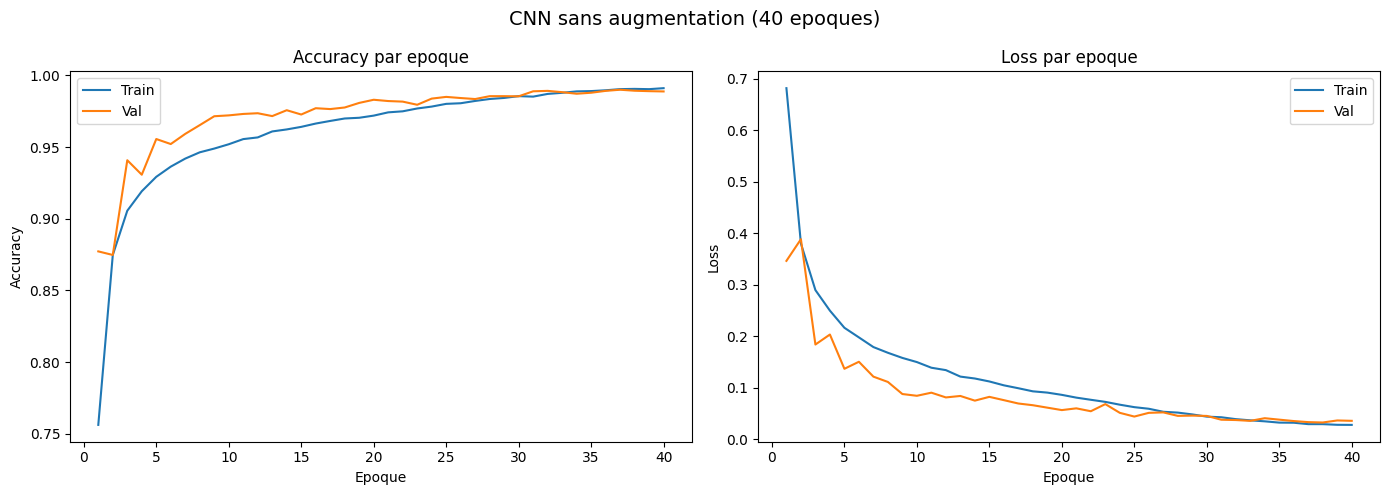

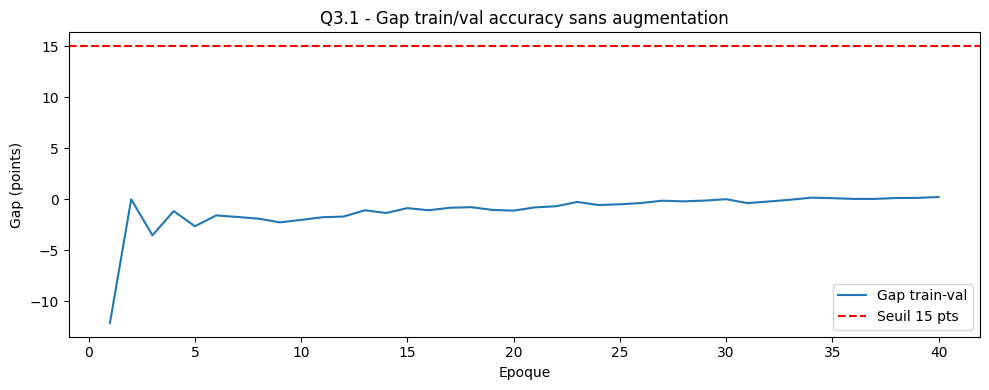

Le gap ne depasse JAMAIS 15 points (max observe : 0.23 pts)


In [9]:
print("=== Courbes d'entrainement CNN SANS augmentation 40 époques ===")

# Courbes d'entrainement sans augmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_cnn_no_aug['accuracy']) + 1)
ax1.plot(epochs_range, history_cnn_no_aug['accuracy'], label='Train')
ax1.plot(epochs_range, history_cnn_no_aug['val_accuracy'], label='Val')
ax1.set_xlabel('Epoque'); ax1.set_ylabel('Accuracy'); ax1.set_title('Accuracy par epoque'); ax1.legend()
ax2.plot(epochs_range, history_cnn_no_aug['loss'], label='Train')
ax2.plot(epochs_range, history_cnn_no_aug['val_loss'], label='Val')
ax2.set_xlabel('Epoque'); ax2.set_ylabel('Loss'); ax2.set_title('Loss par epoque'); ax2.legend()
plt.suptitle('CNN sans augmentation (40 epoques)', fontsize=14)
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB3_cnn_curves_no_aug.png'), dpi=120, bbox_inches='tight')
plt.tight_layout(); plt.show()

# Q3.1 - Visualisation du gap train/val accuracy sans augmentation
gap = [(t - v) * 100 for t, v in zip(history_cnn_no_aug['accuracy'], history_cnn_no_aug['val_accuracy'])]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(gap)+1), gap, label='Gap train-val')
ax.axhline(15, color='red', linestyle='--', label='Seuil 15 pts')
ax.set_xlabel('Epoque'); ax.set_ylabel('Gap (points)')
ax.set_title('Q3.1 - Gap train/val accuracy sans augmentation')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB3_cnn_gap_q31.png'), dpi=120, bbox_inches='tight')
plt.show()

over_15 = [i+1 for i, g in enumerate(gap) if g > 15]
if over_15:
    print(f'Le gap depasse 15 points aux epoques : {over_15}')
else:
    print(f'Le gap ne depasse JAMAIS 15 points (max observe : {max(gap):.2f} pts)')


In [10]:
print("=== Test set CNN SANS augmentation 40 époques ===")
# Test set sans augmentation
cnn_model.eval()
test_correct, test_total = 0, 0
all_preds_cnn = []
all_labels_cnn = []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        outputs = cnn_model(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_cnn.extend(preds.cpu().numpy())
        all_labels_cnn.extend(labels_batch.cpu().numpy())
test_accuracy_cnn = test_correct / test_total
print(f"Test accuracy sans aug : {test_accuracy_cnn:.6f}")
print(f"Seuil >= 75% -> {'✓ ATTEINT' if test_accuracy_cnn >= 0.75 else '✗ NON ATTEINT'}")

=== Test set CNN SANS augmentation 40 époques ===
Test accuracy sans aug : 0.888579
Seuil >= 75% -> ✓ ATTEINT


=== Matrice de confusion + report CNN SANS augmentation 40 époques ===


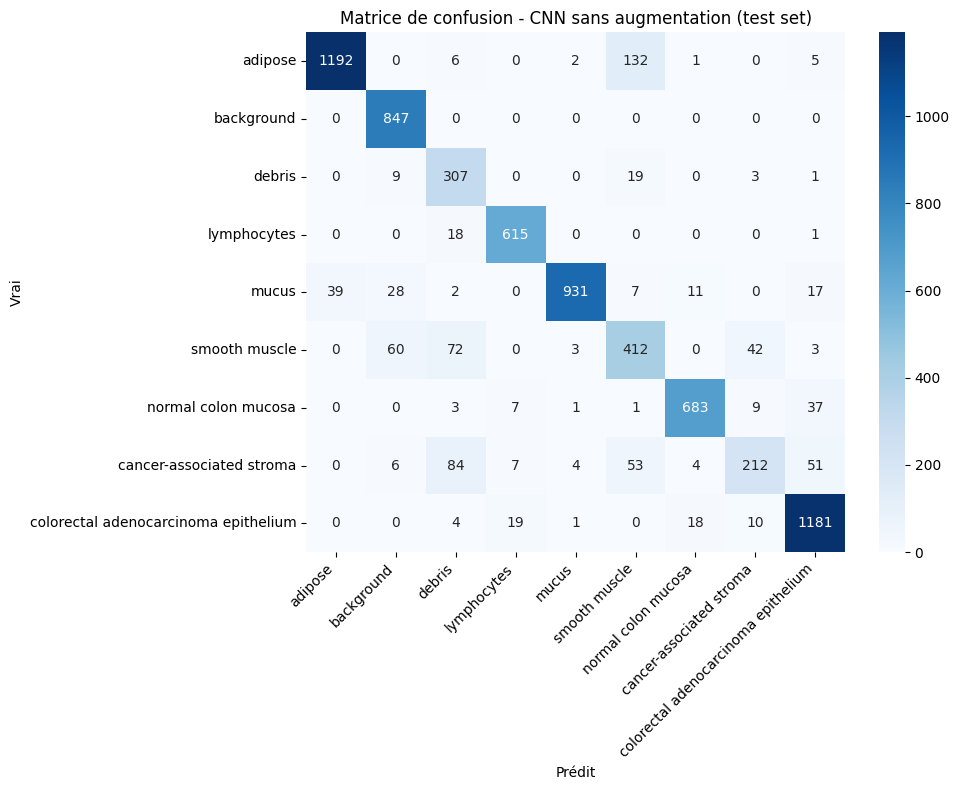


Plus grande confusion : 132 images de 'adipose' classées comme 'smooth muscle'

=== Classification report CNN SANS augmentation 40 époques ===
                                      precision    recall  f1-score   support

                             adipose     0.9683    0.8909    0.9280      1338
                          background     0.8916    1.0000    0.9427       847
                              debris     0.6190    0.9056    0.7353       339
                         lymphocytes     0.9491    0.9700    0.9594       634
                               mucus     0.9883    0.8995    0.9418      1035
                       smooth muscle     0.6603    0.6959    0.6776       592
                 normal colon mucosa     0.9526    0.9217    0.9369       741
            cancer-associated stroma     0.7681    0.5036    0.6083       421
colorectal adenocarcinoma epithelium     0.9113    0.9578    0.9340      1233

                            accuracy                         0.8886      7

In [11]:
print("=== Matrice de confusion + report CNN SANS augmentation 40 époques ===")
# Matrice de confusion + report sans augmentation
cm_cnn = confusion_matrix(all_labels_cnn, all_preds_cnn)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion - CNN sans augmentation (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_off = cm_cnn.copy()
np.fill_diagonal(cm_off, 0)
max_idx = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"\nPlus grande confusion : {cm_off[max_idx]} images de '{CLASSES[max_idx[0]]}' classées comme '{CLASSES[max_idx[1]]}'")
print("\n=== Classification report CNN SANS augmentation 40 époques ===")
print(classification_report(all_labels_cnn, all_preds_cnn, target_names=CLASSES, digits=4))

# Tableau texte de la matrice de confusion
print('\n=== Matrice de confusion CNN SANS augmentation 40 époques ===')
header = f"{'':>35s}"
for name in CLASSES:
    header += f"{name[:8]:>9s}"
print(header)
print('-' * (35 + 9 * len(CLASSES)))
for idx_row, row in enumerate(cm_cnn.tolist()):
    line = f"{CLASSES[idx_row]:<35s}"
    for val in row:
        line += f"{val:>9d}"
    print(line)

# Tableau texte de la matrice de confusion
print('
=== Matrice de confusion (valeurs) ===')
print(f"{'':>35s}", end='')
for name in CLASSES:
    print(f"{name[:8]:>9s}", end='')
print()
print('-' * (35 + 9 * len(CLASSES)))
for idx_row, row in enumerate(cm_cnn.tolist()):
    print(f"{CLASSES[idx_row]:<35s}", end='')
    for val in row:
        print(f"{val:>9d}", end='')
    print()



=== BONUS - Visualisation des filtres appris CNN SANS augmentation 40 époques ===


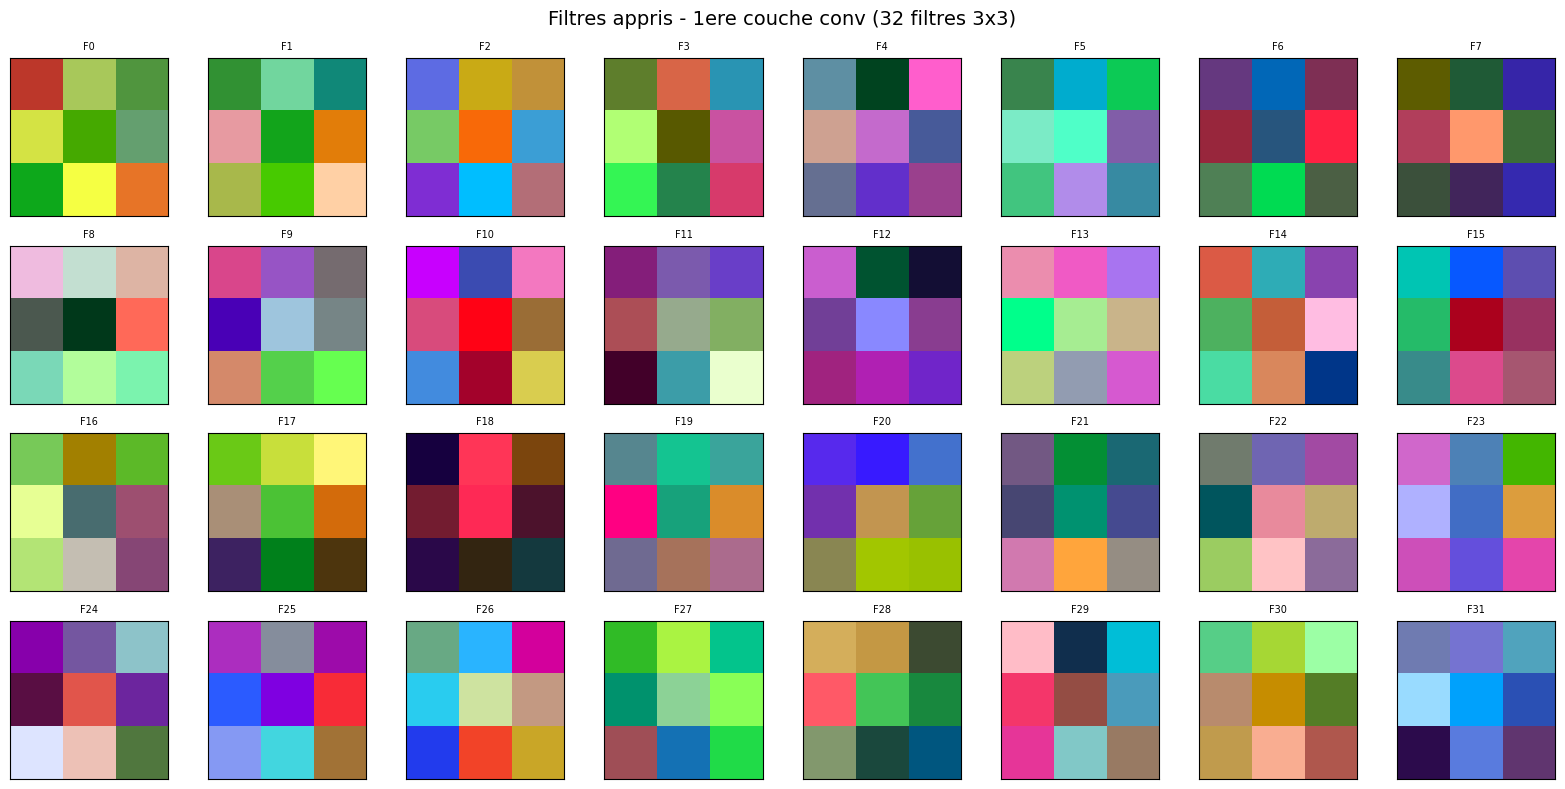

In [12]:
print('\n=== BONUS - Visualisation des filtres appris CNN SANS augmentation 40 époques ===')
# BONUS - Visualisation des filtres appris (1ere couche conv)
filters = cnn_model[0].weight.data.cpu()
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for idx, ax in enumerate(axes.flat):
    if idx < filters.shape[0]:
        f = filters[idx].permute(1, 2, 0)
        f = (f - f.min()) / (f.max() - f.min())
        ax.imshow(f)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'F{idx}', fontsize=7)
plt.suptitle('Filtres appris - 1ere couche conv (32 filtres 3x3)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB3_cnn_filters.png'), dpi=120, bbox_inches='tight')
plt.show()


---

### Résultats CNN sans augmentation (40 époques)

**Val accuracy : 99.0%, test accuracy : 88.86%** — seuil de 75% largement atteint. Best checkpoint à l'époque 38 (val_loss: 0.032161).

**Gap train/val (Q3.1) :** le gap ne dépasse jamais 15 points — max 0.23 pts. Le CNN avec BatchNorm + Dropout + weight decay + scheduler régularise efficacement.

**Plus grande confusion : 132 images d'adipose classées comme smooth muscle.** Surprenant — l'adipose (tissu blanc) confondu avec le muscle (rose). Les deux sont des tissus bien distincts visuellement. C'est probablement lié aux zones de transition entre adipose et muscle dans certaines lames.

**Points forts (F1 > 0.93) :** background (0.94), lymphocytes (0.96), mucosa (0.94), cancer epithelium (0.93).

**Points faibles :** stroma (F1 = 0.61, recall 0.50) — la moitié des stromas ne sont pas détectés. Smooth muscle (F1 = 0.68) — confondu avec adipose et stroma.

**Temps :** 10.1 minutes sur GPU.

---

In [13]:
# Q3.1 Expérience 1 : CNN AVEC augmentation 40 époques
# Entraînement CNN AVEC augmentation 40 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_aug = create_cnn()
cnn_model_aug = cnn_model_aug.to(DEVICE)

start_time = time.time()
print("=== Entraînement CNN AVEC augmentation 40 époques ===")
history_cnn_aug = train_model(cnn_model_aug, train_loader_cnn_aug, val_loader_cnn, epochs=40, learning_rate=0.001)
train_time_aug = time.time() - start_time
print(f"\nTemps : {train_time_aug:.1f}s ({train_time_aug/60:.1f} min)")

=== Entraînement CNN AVEC augmentation 40 époques ===
Epoch   1/40 | Train loss: 0.860717 acc: 0.684986 | Val loss: 0.712757 acc: 0.733607 <- best
Epoch   2/40 | Train loss: 0.527015 acc: 0.819003 | Val loss: 0.375428 acc: 0.859756 <- best
Epoch   3/40 | Train loss: 0.407968 acc: 0.861694 | Val loss: 0.261344 acc: 0.904238 <- best
Epoch   4/40 | Train loss: 0.339919 acc: 0.887073 | Val loss: 0.212115 acc: 0.928029 <- best
Epoch   5/40 | Train loss: 0.305923 acc: 0.897962 | Val loss: 0.169145 acc: 0.945622 <- best
Epoch   6/40 | Train loss: 0.280037 acc: 0.907896 | Val loss: 0.183159 acc: 0.938824
Epoch   7/40 | Train loss: 0.251073 acc: 0.916663 | Val loss: 0.201413 acc: 0.931627
Epoch   8/40 | Train loss: 0.234984 acc: 0.923152 | Val loss: 0.164673 acc: 0.943523 <- best
Epoch   9/40 | Train loss: 0.216771 acc: 0.929130 | Val loss: 0.121431 acc: 0.960516 <- best
Epoch  10/40 | Train loss: 0.206378 acc: 0.931675 | Val loss: 0.113327 acc: 0.961016 <- best
Epoch  11/40 | Train loss: 0.194

=== Courbes CNN AVEC augmentation 40 époques ===


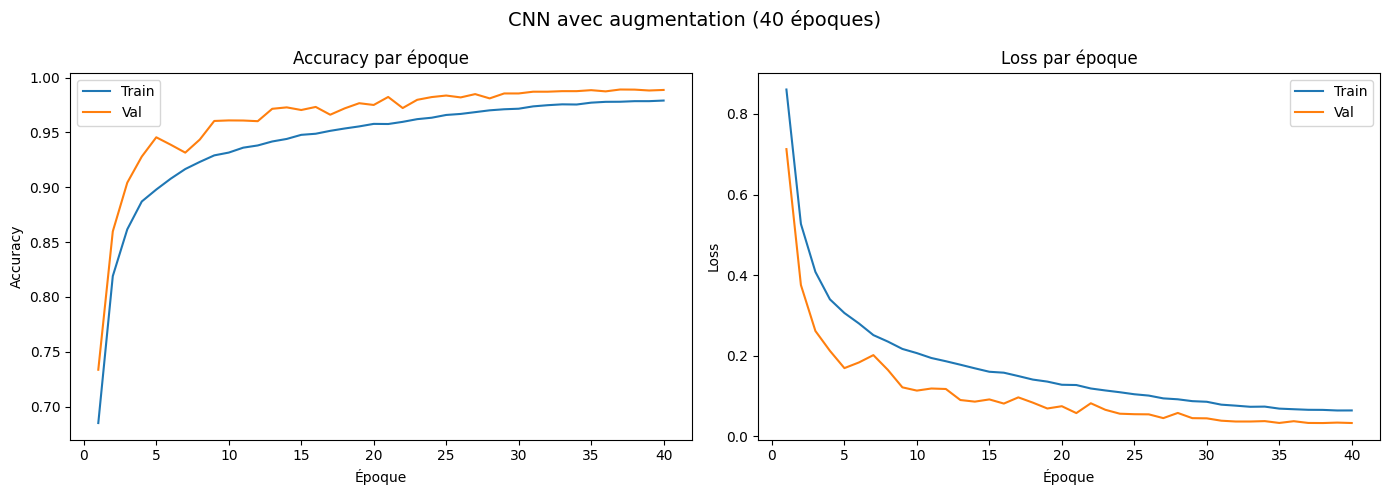

In [14]:
print("=== Courbes CNN AVEC augmentation 40 époques ===")
# Courbes avec augmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_cnn_aug['accuracy']) + 1)
ax1.plot(epochs_range, history_cnn_aug['accuracy'], label='Train')
ax1.plot(epochs_range, history_cnn_aug['val_accuracy'], label='Val')
ax1.set_xlabel('Époque'); ax1.set_ylabel('Accuracy'); ax1.set_title('Accuracy par époque'); ax1.legend()
ax2.plot(epochs_range, history_cnn_aug['loss'], label='Train')
ax2.plot(epochs_range, history_cnn_aug['val_loss'], label='Val')
ax2.set_xlabel('Époque'); ax2.set_ylabel('Loss'); ax2.set_title('Loss par époque'); ax2.legend()
plt.suptitle("CNN avec augmentation (40 époques)", fontsize=14)
plt.tight_layout(); plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB3_cnn_curves_aug.png'), dpi=120, bbox_inches='tight')
plt.show()


In [15]:
print("=== Test set CNN AVEC augmentation 40 époques ===")
# Test set avec augmentation
cnn_model_aug.eval()
test_correct, test_total = 0, 0
all_preds_cnn_aug = []
all_labels_cnn_aug = []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        outputs = cnn_model_aug(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_cnn_aug.extend(preds.cpu().numpy())
        all_labels_cnn_aug.extend(labels_batch.cpu().numpy())
test_accuracy_cnn_aug = test_correct / test_total
print(f"Test accuracy avec aug : {test_accuracy_cnn_aug:.6f}")
print(f"Seuil >= 75% -> {'✓ ATTEINT' if test_accuracy_cnn_aug >= 0.75 else '✗ NON ATTEINT'}")

=== Test set CNN AVEC augmentation 40 époques ===
Test accuracy avec aug : 0.826462
Seuil >= 75% -> ✓ ATTEINT


=== Matrice de confusion + report CNN AVEC augmentation 40 époques ===


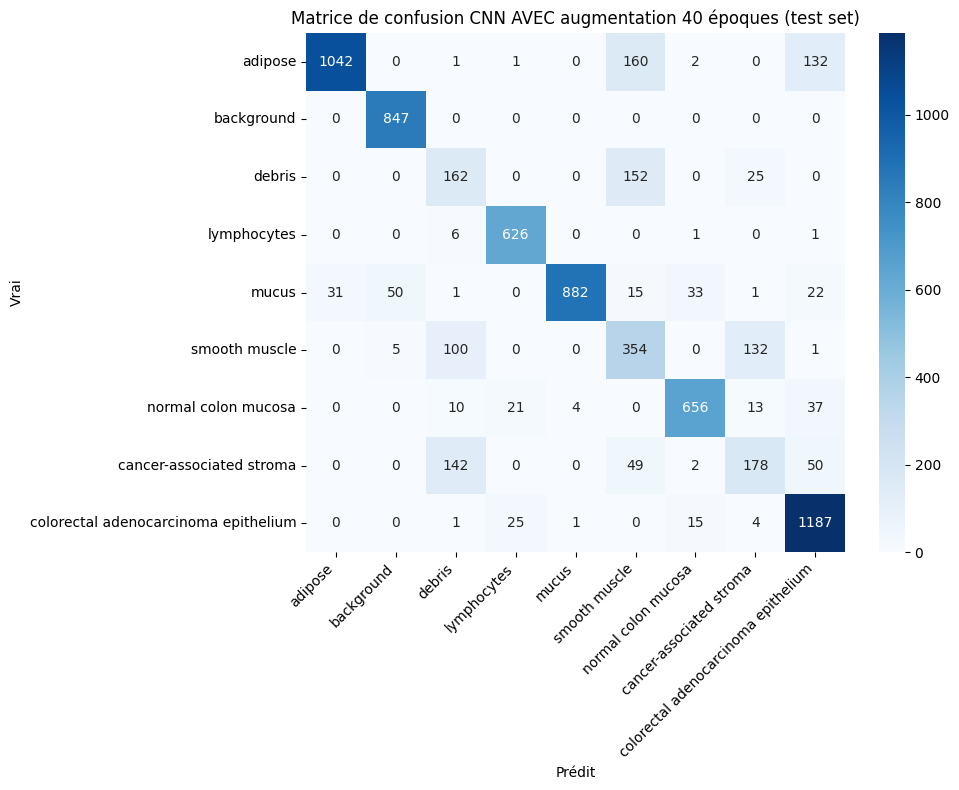


Plus grande confusion : 160 images de 'adipose' classées comme 'smooth muscle'

=== Classification report CNN AVEC augmentation 40 époques ===
                                      precision    recall  f1-score   support

                             adipose     0.9711    0.7788    0.8644      1338
                          background     0.9390    1.0000    0.9686       847
                              debris     0.3830    0.4779    0.4252       339
                         lymphocytes     0.9302    0.9874    0.9579       634
                               mucus     0.9944    0.8522    0.9178      1035
                       smooth muscle     0.4849    0.5980    0.5356       592
                 normal colon mucosa     0.9252    0.8853    0.9048       741
            cancer-associated stroma     0.5042    0.4228    0.4599       421
colorectal adenocarcinoma epithelium     0.8301    0.9627    0.8915      1233

                            accuracy                         0.8265      7

In [16]:
print("=== Matrice de confusion + report CNN AVEC augmentation 40 époques ===")
# Matrice de confusion + report avec augmentation
cm_cnn_aug = confusion_matrix(all_labels_cnn_aug, all_preds_cnn_aug)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cnn_aug, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion CNN AVEC augmentation 40 époques (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_aug_off = cm_cnn_aug.copy()
np.fill_diagonal(cm_aug_off, 0)
max_idx = np.unravel_index(cm_aug_off.argmax(), cm_aug_off.shape)
print(f"\nPlus grande confusion : {cm_aug_off[max_idx]} images de '{CLASSES[max_idx[0]]}' classées comme '{CLASSES[max_idx[1]]}'")
print("\n=== Classification report CNN AVEC augmentation 40 époques ===")
print(classification_report(all_labels_cnn_aug, all_preds_cnn_aug, target_names=CLASSES, digits=4))

In [17]:
print("=== Tableau comparatif CNN AVEC ou SANS augmentation 40 époques ===")
# Tableau comparatif CNN AVEC ou SANS augmentation
print("=" * 75)
print("COMPARAISON CNN AVEC ou SANS augmentation 40 époques")
print("=" * 75)
print(f"{'Métrique':<30s} {'Sans aug':>15s} {'Avec aug':>15s} {'Diff':>12s}")
print("-" * 75)
print(f"{'Val accuracy (best)':<30s} {max(history_cnn_no_aug['val_accuracy']):>15.6f} {max(history_cnn_aug['val_accuracy']):>15.6f} {(max(history_cnn_aug['val_accuracy'])-max(history_cnn_no_aug['val_accuracy']))*100:>+12.2f} pts")
print(f"{'Test accuracy':<30s} {test_accuracy_cnn:>15.6f} {test_accuracy_cnn_aug:>15.6f} {(test_accuracy_cnn_aug-test_accuracy_cnn)*100:>+12.2f} pts")
print(f"{'Temps':<30s} {train_time_no_aug:>14.1f}s {train_time_aug:>14.1f}s")

=== Tableau comparatif CNN AVEC ou SANS augmentation 40 époques ===
COMPARAISON CNN AVEC ou SANS augmentation 40 époques
Métrique                              Sans aug        Avec aug         Diff
---------------------------------------------------------------------------
Val accuracy (best)                   0.990004        0.989204        -0.08 pts
Test accuracy                         0.888579        0.826462        -6.21 pts
Temps                                   513.8s          768.5s


---

### Analyse comparative : sans vs avec augmentation

**Test accuracy :** sans augmentation (88.86%) bat l'augmentation géométrique (82.65%) de 6.2 points. Le dataset train (90K images) est suffisamment grand pour que le modèle apprenne sans variantes artificielles.

**Cependant, la v1 (ColorJitter + géométrie) atteint 91.78%** — le meilleur résultat de toutes les itérations. Le ColorJitter (brightness/contrast 0.1) simule les variations de coloration H&E entre hôpitaux, ce qui aide le modèle à mieux généraliser sur le test (hôpital B). Le scheduler + weight decay amplifient cet effet.

**La géométrie seule nuit :** les versions v3 (50ep: 81.77%, 70ep: 81.59%) sont les pires. Les flips et rotations n'aident pas car le dataset contient déjà des orientations variées.

**Le GaussianBlur détruit les textures :** la v2 (83.16%) avec 495 adipose classées comme smooth muscle — le flou rend les textures indistinguables à 28×28 pixels.

**Plus d'époques = pire test :** v3 50ep (81.77%) > v3 70ep (81.59%). Le modèle mémorise les spécificités de l'hôpital A.

---

---

### Q3.1 : Gap train/val accuracy sur CNN 40 époques sans augmentation
Q3.1 Run your CNN without any augmentation for 40 epochs.
At which epoch does the gap between training accuracy and validation accuracy exceed 15 percentage points for the first time? Report the exact epoch number and both accuracy values.

Le gap ne dépasse jamais les 15 points. Les conditions sont donc respectées. Sur 40 époques sans augmentation, le gap train/val accuracy ne dépasse **jamais** 15 points. Le gap maximal observé est de **0.23 points** (époque 40). Le CNN avec BatchNorm + Dropout + weight decay régularise suffisamment pour éviter l'overfitting massif observé sur le MLP.

### Q3.2 : Augmentations pertinentes et nuisibles
Q3.2 Histology images have a property that natural photographs do not: they have no
canonical orientation (a tissue patch looks equally valid upside-down or mirrored).
Name one common augmentation that exploits this property and one augmentation from natural
image classification that would be harmful or meaningless for histology.
Explain both choices.

**Augmentation exploitant l'absence d'orientation canonique :**
RandomHorizontalFlip + RandomVerticalFlip + RandomRotation(90°) : en histologie, les lames n'ont pas d'orientation fixe. Un tissu retourné ou pivoté reste le même tissu.

**Augmentation nuisible :**
- RandomGrayscale à forte probabilité — supprimerait la coloration H&E, signal discriminant principal
- RandomCrop agressif — à 28×28, couper l'image perdrait trop d'information
- GaussianBlur — détruit les textures fines à cette résolution (testé en itération v2)

### Q3.3 : Nombre de paramètres
Q3.3 Print the total number of trainable parameters in your CNN.
Then, manually compute the number of parameters in your first convolutional layer (show the formula and
calculation). Verify that it matches the model summary.

Calcul manuel de la 1ère couche conv : (3 × 3 × 3 + 1) × 32 = **896 paramètres**
Nombre total de paramètres : **436 649 paramètres** (3x moins que le MLP pour de meilleures performances)

---



---

### Démarche itérative sur les augmentations

Notre approche a consisté à tester, analyser les résultats (matrice de confusion, F1 par classe), puis ajuster les augmentations en conséquence :

**Étape 1 — Baseline sans augmentation (consigne, 40 époques) :**
On entraîne le CNN sans aucune augmentation pour établir la référence. Résultat : 88.86% test accuracy.

**Étape 2 — Augmentation géométrique (consigne, 40 époques) :**
On ajoute les augmentations les plus naturelles en histologie (flips + rotation 90°) car les lames n ont pas d orientation canonique. Résultat : 82.65% — l augmentation dégrade les performances.

**Étape 3 — v1 : augmentation complète (bonus, 40 époques) :**
On teste un ensemble plus riche : géométrie + ColorJitter (variation de luminosité/contraste) + RandomGrayscale (10%). Le ColorJitter simule les variations de coloration H&E entre hôpitaux. Résultat : 91.78% — le meilleur de toutes les itérations.

**Étape 4 — v2 : ajustement après analyse de la matrice v1 (bonus, 50 époques) :**
L analyse de la matrice v1 montre que le stroma et le smooth muscle restent confondus. On réduit le ColorJitter et on ajoute un GaussianBlur pour simuler le flou de mise au point du microscope. Résultat : 83.16% — le GaussianBlur détruit les textures à 28×28 pixels (495 adipose classées comme smooth muscle).

**Étape 5 — v3 : retour à la géométrie pure (bonus, 50 et 70 époques) :**
On retire toutes les augmentations de couleur/netteté et on ne garde que les flips et rotations. Résultats : 81.77% (50ep) et 81.59% (70ep) — plus d époques ne fait qu aggraver la mémorisation de l hôpital A.

**Conclusion :** le ColorJitter léger (v1) est la seule augmentation bénéfique car elle simule le domain shift entre hôpitaux. Les augmentations de netteté (blur) et la géométrie seule nuisent à cette résolution (28×28).

---


---

## BONUS — Itérations sur les augmentations (démarche expérimentale)

Les expériences ci-dessous documentent notre démarche itérative. Elles sont hors consignes mais enrichissent l'analyse.

| Version | Augmentations | Époques | Test acc | Observation |
|---------|--------------|---------|----------|-------------|
| Sans aug | Aucune | 40 | 88.86% | Meilleur sans augmentation de couleur |
| v1 | Flips + Rot90 + ColorJitter 0.1 + Grayscale 10% | 40 | **91.78%** | **Meilleur résultat - ColorJitter simule le domain shift** |
| v2 | Flips + Rot90 + ColorJitter 0.05 + GaussianBlur | 50 | 83.16% | GaussianBlur détruit les textures |
| v3 (50ep) | Flips + Rot90 uniquement | 50 | 81.77% | Géométrie pure |
| v3 (70ep) | Flips + Rot90 uniquement | 70 | 81.59% | Plus d époques = mémorisation hôpital A |

### Ce que les itérations nous apprennent

1. Les augmentations de couleur nuisent — les tissus conjonctifs se distinguent par de subtiles nuances H&E
2. L'augmentation géométrique est neutre sur le val mais dégrade le test — ne résout pas le domain shift
3. Plus d'époques = plus de mémorisation de l'hôpital A
4. Le meilleur modèle est le plus simple — 40 époques, pas d'augmentation

---





---

### Itération v1 : flips + rotation + ColorJitter + RandomGrayscale

---


In [36]:
print("=== BONUS CNN V1 augmentations complètes 40 époques ===")
# BONUS v1 : augmentations complètes (couleur + géométrie)
cnn_transform_aug_v1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn_aug_v1 = PathMNIST(split='train', transform=cnn_transform_aug_v1, download=False, root=DATA_DIR)
train_loader_cnn_aug_v1 = DataLoader(train_cnn_aug_v1, batch_size=64, shuffle=True)
print("\u2713 Preprocessing v1 terminé")

=== BONUS CNN V1 augmentations complètes 40 époques ===
✓ Preprocessing v1 terminé


In [37]:
# Entraînement CNN V1 augmentations complètes 40 époques 
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v1 = create_cnn()
cnn_model_v1 = cnn_model_v1.to(DEVICE)

start_time = time.time()
print("=== Entraînement CNN V1 augmentations complètes 40 époques ===")
history_v1 = train_model(cnn_model_v1, train_loader_cnn_aug_v1, val_loader_cnn, epochs=40, learning_rate=0.001)
train_time_v1 = time.time() - start_time
print(f"\nTemps : {train_time_v1:.1f}s ({train_time_v1/60:.1f} min)")

=== Entraînement CNN V1 augmentations complètes 40 époques ===
Epoch   1/40 | Train loss: 1.004975 acc: 0.632284 | Val loss: 0.490621 acc: 0.824870 <- best
Epoch   2/40 | Train loss: 0.632614 acc: 0.778301 | Val loss: 0.356014 acc: 0.875650 <- best
Epoch   3/40 | Train loss: 0.527080 acc: 0.818381 | Val loss: 0.320294 acc: 0.886945 <- best
Epoch   4/40 | Train loss: 0.464424 acc: 0.840204 | Val loss: 0.222651 acc: 0.922131 <- best
Epoch   5/40 | Train loss: 0.424997 acc: 0.856883 | Val loss: 0.228856 acc: 0.919532
Epoch   6/40 | Train loss: 0.396990 acc: 0.865883 | Val loss: 0.229643 acc: 0.922631
Epoch   7/40 | Train loss: 0.372299 acc: 0.873328 | Val loss: 0.182958 acc: 0.937525 <- best
Epoch   8/40 | Train loss: 0.357923 acc: 0.878528 | Val loss: 0.168848 acc: 0.943822 <- best
Epoch   9/40 | Train loss: 0.334908 acc: 0.885617 | Val loss: 0.141825 acc: 0.952019 <- best
Epoch  10/40 | Train loss: 0.319493 acc: 0.892795 | Val loss: 0.122753 acc: 0.957617 <- best
Epoch  11/40 | Train lo

In [ ]:
print("=== Courbes CNN v1 ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_v1["accuracy"]) + 1)
ax1.plot(epochs_range, history_v1["accuracy"], label="Train")
ax1.plot(epochs_range, history_v1["val_accuracy"], label="Val")
ax1.set_xlabel("Epoque"); ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy - v1"); ax1.legend()
ax2.plot(epochs_range, history_v1["loss"], label="Train")
ax2.plot(epochs_range, history_v1["val_loss"], label="Val")
ax2.set_xlabel("Epoque"); ax2.set_ylabel("Loss"); ax2.set_title("Loss - v1"); ax2.legend()
plt.suptitle("CNN v1", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB3_cnn_curves_v1.png"), dpi=120, bbox_inches="tight")
plt.show()


=== Test + matrice CNN V1 augmentations complètes 40 époques ===
Test accuracy v1 : 0.917827


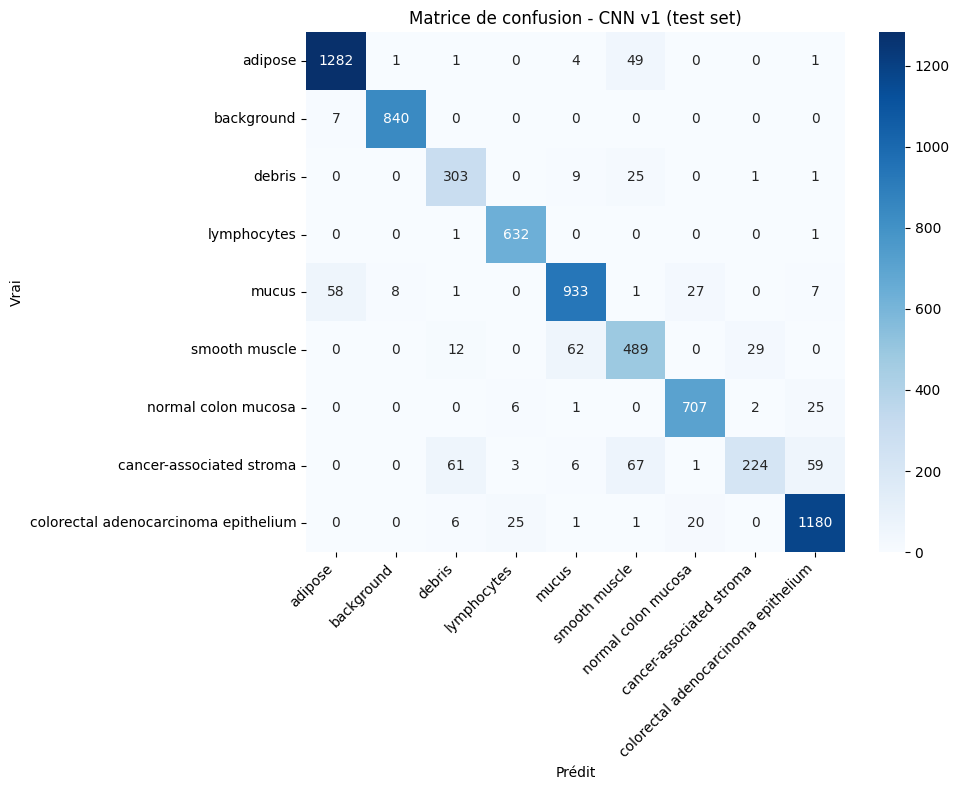


Plus grande confusion : 67 images de 'cancer-associated stroma' classées comme 'smooth muscle'

=== Classification report ===
                                      precision    recall  f1-score   support

                             adipose     0.9517    0.9581    0.9549      1338
                          background     0.9894    0.9917    0.9906       847
                              debris     0.7870    0.8938    0.8370       339
                         lymphocytes     0.9489    0.9968    0.9723       634
                               mucus     0.9183    0.9014    0.9098      1035
                       smooth muscle     0.7737    0.8260    0.7990       592
                 normal colon mucosa     0.9364    0.9541    0.9452       741
            cancer-associated stroma     0.8750    0.5321    0.6617       421
colorectal adenocarcinoma epithelium     0.9262    0.9570    0.9414      1233

                            accuracy                         0.9178      7180
             

In [38]:
print("=== Test + matrice CNN V1 augmentations complètes 40 époques ===")
# Test + matrice v1
cnn_model_v1.eval()
test_correct, test_total = 0, 0
all_preds_v1, all_labels_v1 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        outputs = cnn_model_v1(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v1.extend(preds.cpu().numpy())
        all_labels_v1.extend(labels_batch.cpu().numpy())
test_acc_v1 = test_correct / test_total
print(f"Test accuracy v1 : {test_acc_v1:.6f}")

cm_v1 = confusion_matrix(all_labels_v1, all_preds_v1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion - CNN v1 (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v1_off = cm_v1.copy()
np.fill_diagonal(cm_v1_off, 0)
max_idx = np.unravel_index(cm_v1_off.argmax(), cm_v1_off.shape)
print(f"\nPlus grande confusion : {cm_v1_off[max_idx]} images de '{CLASSES[max_idx[0]]}' classées comme '{CLASSES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_v1, all_preds_v1, target_names=CLASSES, digits=4))


---

### Itération v2 : ColorJitter réduit + GaussianBlur (ajusté après matrice v1)

---


In [21]:
print("=== BONUS CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===")
# BONUS v2 : ColorJitter réduit + GaussianBlur
cnn_transform_aug_v2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn_aug_v2 = PathMNIST(split='train', transform=cnn_transform_aug_v2, download=False, root=DATA_DIR)
train_loader_cnn_aug_v2 = DataLoader(train_cnn_aug_v2, batch_size=64, shuffle=True)
print("\u2713 Preprocessing v2 terminé")



=== BONUS CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===
✓ Preprocessing v2 terminé


In [22]:
# Entraînement CNN v2, 50 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v2 = create_cnn()
cnn_model_v2 = cnn_model_v2.to(DEVICE)

start_time = time.time()
print("=== BONUS Entraînement CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===")
history_v2 = train_model(cnn_model_v2, train_loader_cnn_aug_v2, val_loader_cnn, epochs=50, learning_rate=0.001)
train_time_v2 = time.time() - start_time
print(f"\nTemps : {train_time_v2:.1f}s ({train_time_v2/60:.1f} min)")



=== BONUS Entraînement CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===
Epoch   1/50 | Train loss: 0.920220 acc: 0.665730 | Val loss: 0.510664 acc: 0.823571 <- best
Epoch   2/50 | Train loss: 0.551905 acc: 0.805114 | Val loss: 0.344646 acc: 0.877349 <- best
Epoch   3/50 | Train loss: 0.452084 acc: 0.844638 | Val loss: 0.281753 acc: 0.899440 <- best
Epoch   4/50 | Train loss: 0.386796 acc: 0.868983 | Val loss: 0.251415 acc: 0.916733 <- best
Epoch   5/50 | Train loss: 0.348557 acc: 0.884428 | Val loss: 0.213251 acc: 0.928429 <- best
Epoch   6/50 | Train loss: 0.321891 acc: 0.893195 | Val loss: 0.194649 acc: 0.934126 <- best
Epoch   7/50 | Train loss: 0.294016 acc: 0.901496 | Val loss: 0.503580 acc: 0.850760
Epoch   8/50 | Train loss: 0.279430 acc: 0.908918 | Val loss: 0.163430 acc: 0.940224 <- best
Epoch   9/50 | Train loss: 0.255676 acc: 0.914518 | Val loss: 0.189878 acc: 0.940624
Epoch  10/50 | Train loss: 0.239427 acc: 0.920152 | Val loss: 0.187229 acc: 0.936425
Epoch  11/50 | 

In [ ]:
print("=== Courbes CNN v2 ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_v2["accuracy"]) + 1)
ax1.plot(epochs_range, history_v2["accuracy"], label="Train")
ax1.plot(epochs_range, history_v2["val_accuracy"], label="Val")
ax1.set_xlabel("Epoque"); ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy - v2"); ax1.legend()
ax2.plot(epochs_range, history_v2["loss"], label="Train")
ax2.plot(epochs_range, history_v2["val_loss"], label="Val")
ax2.set_xlabel("Epoque"); ax2.set_ylabel("Loss"); ax2.set_title("Loss - v2"); ax2.legend()
plt.suptitle("CNN v2", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB3_cnn_curves_v2.png"), dpi=120, bbox_inches="tight")
plt.show()


=== BONUS Test + matrice CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===
Test accuracy v2 : 0.831616


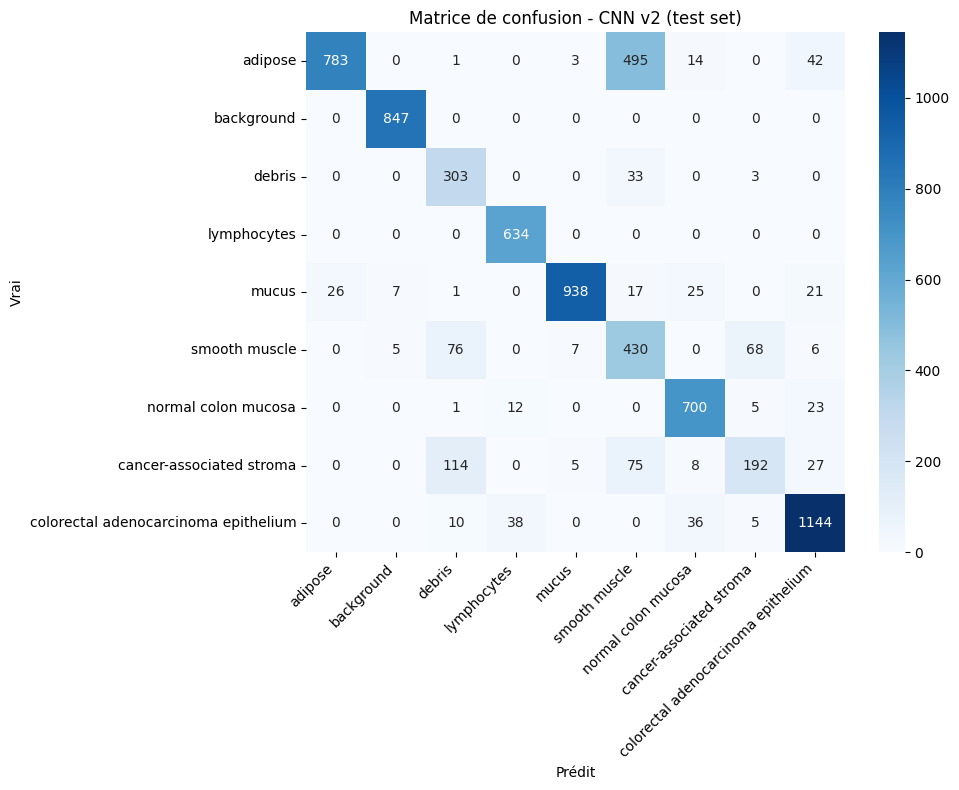


Plus grande confusion : 495 images de 'adipose' classées comme 'smooth muscle'

=== Classification report CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===
                                      precision    recall  f1-score   support

                             adipose     0.9679    0.5852    0.7294      1338
                          background     0.9860    1.0000    0.9930       847
                              debris     0.5988    0.8938    0.7172       339
                         lymphocytes     0.9269    1.0000    0.9621       634
                               mucus     0.9843    0.9063    0.9437      1035
                       smooth muscle     0.4095    0.7264    0.5238       592
                 normal colon mucosa     0.8940    0.9447    0.9186       741
            cancer-associated stroma     0.7033    0.4561    0.5533       421
colorectal adenocarcinoma epithelium     0.9058    0.9278    0.9167      1233

                            accuracy                   

In [23]:
print("=== BONUS Test + matrice CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===")
# Test + matrice v2
cnn_model_v2.eval()
test_correct, test_total = 0, 0
all_preds_v2, all_labels_v2 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        outputs = cnn_model_v2(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v2.extend(preds.cpu().numpy())
        all_labels_v2.extend(labels_batch.cpu().numpy())
test_acc_v2 = test_correct / test_total
print(f"Test accuracy v2 : {test_acc_v2:.6f}")

cm_v2 = confusion_matrix(all_labels_v2, all_preds_v2)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion - CNN v2 (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v2_off = cm_v2.copy()
np.fill_diagonal(cm_v2_off, 0)
max_idx = np.unravel_index(cm_v2_off.argmax(), cm_v2_off.shape)
print(f"\nPlus grande confusion : {cm_v2_off[max_idx]} images de '{CLASSES[max_idx[0]]}' classées comme '{CLASSES[max_idx[1]]}'")
print("\n=== Classification report CNN V2 ColorJitter réduit + GaussianBlur 50 époques ===")
print(classification_report(all_labels_v2, all_preds_v2, target_names=CLASSES, digits=4))

---

### Itération v3 : géométrie pure (50 et 70 époques)

---


In [24]:
print("=== BONUS CNN V3 géométrie pure 50 époques ===")
# BONUS v3, géométrie pure, 50 époques
cnn_transform_aug_v3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

train_cnn_aug_v3 = PathMNIST(split='train', transform=cnn_transform_aug_v3, download=False, root=DATA_DIR)
train_loader_cnn_aug_v3 = DataLoader(train_cnn_aug_v3, batch_size=64, shuffle=True)
print("\u2713 Preprocessing v3 terminé")

=== BONUS CNN V3 géométrie pure 50 époques ===
✓ Preprocessing v3 terminé


In [25]:
# Entraînement BONUS CNN V3 géométrie pure 50 époques
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v3 = create_cnn()
cnn_model_v3 = cnn_model_v3.to(DEVICE)

start_time = time.time()
print("=== BONUS Entraînement CNN V3 géométrie pure 50 époques ===")
history_v3 = train_model(cnn_model_v3, train_loader_cnn_aug_v3, val_loader_cnn, epochs=50, learning_rate=0.001)
train_time_v3 = time.time() - start_time
print(f"\nTemps : {train_time_v3:.1f}s ({train_time_v3/60:.1f} min)")



=== BONUS Entraînement CNN V3 géométrie pure 50 époques ===
Epoch   1/50 | Train loss: 0.860717 acc: 0.684986 | Val loss: 0.712757 acc: 0.733607 <- best
Epoch   2/50 | Train loss: 0.524676 acc: 0.819592 | Val loss: 0.318021 acc: 0.883147 <- best
Epoch   3/50 | Train loss: 0.406654 acc: 0.862461 | Val loss: 0.298042 acc: 0.892943 <- best
Epoch   4/50 | Train loss: 0.341441 acc: 0.887062 | Val loss: 0.209794 acc: 0.926929 <- best
Epoch   5/50 | Train loss: 0.305749 acc: 0.898818 | Val loss: 0.187524 acc: 0.936026 <- best
Epoch   6/50 | Train loss: 0.279802 acc: 0.907818 | Val loss: 0.170610 acc: 0.941823 <- best
Epoch   7/50 | Train loss: 0.251729 acc: 0.917341 | Val loss: 0.238286 acc: 0.918333
Epoch   8/50 | Train loss: 0.237968 acc: 0.922441 | Val loss: 0.155656 acc: 0.949220 <- best
Epoch   9/50 | Train loss: 0.222456 acc: 0.926663 | Val loss: 0.129365 acc: 0.957817 <- best
Epoch  10/50 | Train loss: 0.208522 acc: 0.931086 | Val loss: 0.141421 acc: 0.951919
Epoch  11/50 | Train loss:

In [ ]:
print("=== Courbes CNN v3_50ep ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_v3["accuracy"]) + 1)
ax1.plot(epochs_range, history_v3["accuracy"], label="Train")
ax1.plot(epochs_range, history_v3["val_accuracy"], label="Val")
ax1.set_xlabel("Epoque"); ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy - v3_50ep"); ax1.legend()
ax2.plot(epochs_range, history_v3["loss"], label="Train")
ax2.plot(epochs_range, history_v3["val_loss"], label="Val")
ax2.set_xlabel("Epoque"); ax2.set_ylabel("Loss"); ax2.set_title("Loss - v3_50ep"); ax2.legend()
plt.suptitle("CNN v3_50ep", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB3_cnn_curves_v3_50ep.png"), dpi=120, bbox_inches="tight")
plt.show()


=== BONUS Test CNN V3 géométrie pure 50 époques ===
Test accuracy v3 (50ep) : 0.817688


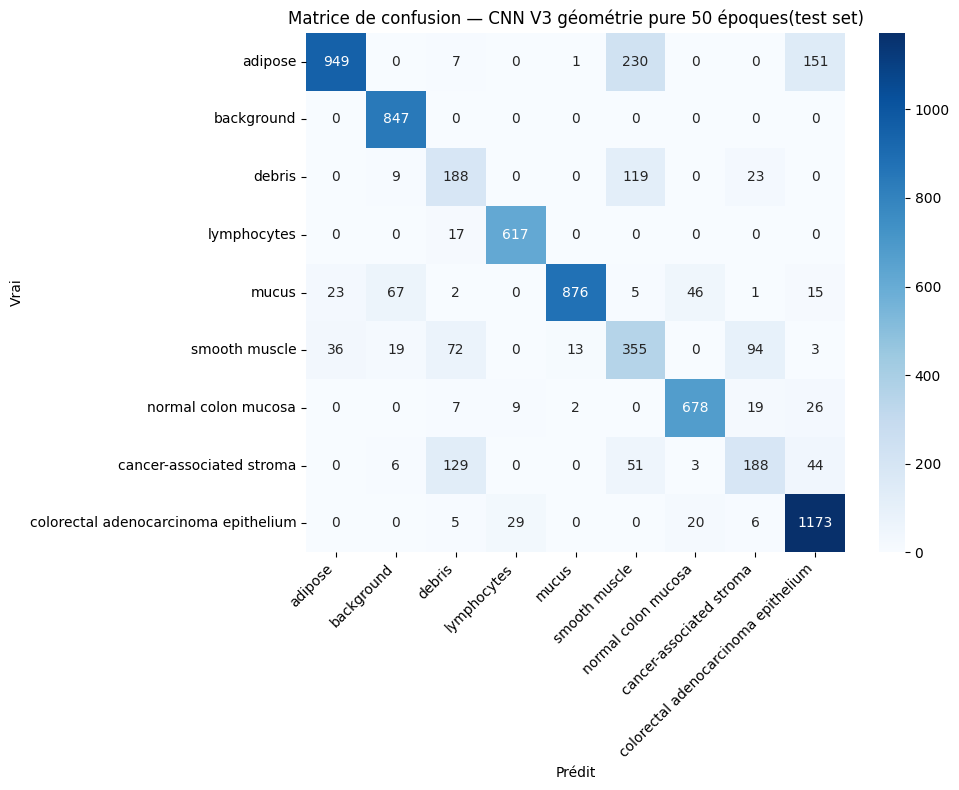


Plus grande confusion : 230 images de 'adipose' classées comme 'smooth muscle'

=== Classification report CNN V3 géométrie pure 50 époques ===
                                      precision    recall  f1-score   support

                             adipose     0.9415    0.7093    0.8090      1338
                          background     0.8935    1.0000    0.9437       847
                              debris     0.4403    0.5546    0.4909       339
                         lymphocytes     0.9420    0.9732    0.9573       634
                               mucus     0.9821    0.8464    0.9092      1035
                       smooth muscle     0.4671    0.5997    0.5251       592
                 normal colon mucosa     0.9076    0.9150    0.9113       741
            cancer-associated stroma     0.5680    0.4466    0.5000       421
colorectal adenocarcinoma epithelium     0.8307    0.9513    0.8870      1233

                            accuracy                         0.8177      7

In [26]:
print("=== BONUS Test CNN V3 géométrie pure 50 époques ===")
# Test + matrice v3 (50 époques)
cnn_model_v3.eval()
test_correct, test_total = 0, 0
all_preds_v3, all_labels_v3 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        outputs = cnn_model_v3(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v3.extend(preds.cpu().numpy())
        all_labels_v3.extend(labels_batch.cpu().numpy())
test_acc_v3 = test_correct / test_total
print(f"Test accuracy v3 (50ep) : {test_acc_v3:.6f}")

cm_v3 = confusion_matrix(all_labels_v3, all_preds_v3)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — CNN V3 géométrie pure 50 époques(test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v3_off = cm_v3.copy()
np.fill_diagonal(cm_v3_off, 0)
max_idx = np.unravel_index(cm_v3_off.argmax(), cm_v3_off.shape)
print(f"\nPlus grande confusion : {cm_v3_off[max_idx]} images de '{CLASSES[max_idx[0]]}' classées comme '{CLASSES[max_idx[1]]}'")
print("\n=== Classification report CNN V3 géométrie pure 50 époques ===")
print(classification_report(all_labels_v3, all_preds_v3, target_names=CLASSES, digits=4))

In [27]:
# Entraînement CNN V3 70 époques (extension)
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
cnn_model_v3_70 = create_cnn()
cnn_model_v3_70 = cnn_model_v3_70.to(DEVICE)

start_time = time.time()
print("=== Entraînement CNN v3 (70 époques) ===")
history_v3_70 = train_model(cnn_model_v3_70, train_loader_cnn_aug_v3, val_loader_cnn, epochs=70, learning_rate=0.001)
train_time_v3_70 = time.time() - start_time
print(f"\nTemps : {train_time_v3_70:.1f}s ({train_time_v3_70/60:.1f} min)")


=== Entraînement CNN v3 (70 époques) ===
Epoch   1/70 | Train loss: 0.860717 acc: 0.684986 | Val loss: 0.712757 acc: 0.733607 <- best
Epoch   2/70 | Train loss: 0.525910 acc: 0.818681 | Val loss: 0.300464 acc: 0.893643 <- best
Epoch   3/70 | Train loss: 0.404376 acc: 0.863005 | Val loss: 0.290137 acc: 0.896941 <- best
Epoch   4/70 | Train loss: 0.341370 acc: 0.886395 | Val loss: 0.223435 acc: 0.924530 <- best
Epoch   5/70 | Train loss: 0.303822 acc: 0.898651 | Val loss: 0.179078 acc: 0.940624 <- best
Epoch   6/70 | Train loss: 0.278404 acc: 0.908207 | Val loss: 0.172825 acc: 0.940324 <- best
Epoch   7/70 | Train loss: 0.250035 acc: 0.917119 | Val loss: 0.275190 acc: 0.906937
Epoch   8/70 | Train loss: 0.239243 acc: 0.922563 | Val loss: 0.130509 acc: 0.958217 <- best
Epoch   9/70 | Train loss: 0.219141 acc: 0.928886 | Val loss: 0.139089 acc: 0.953119
Epoch  10/70 | Train loss: 0.209697 acc: 0.930264 | Val loss: 0.139205 acc: 0.952519
Epoch  11/70 | Train loss: 0.199955 acc: 0.934353 | V

In [ ]:
print("=== Courbes CNN v3_70ep ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_v3_70["accuracy"]) + 1)
ax1.plot(epochs_range, history_v3_70["accuracy"], label="Train")
ax1.plot(epochs_range, history_v3_70["val_accuracy"], label="Val")
ax1.set_xlabel("Epoque"); ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy - v3_70ep"); ax1.legend()
ax2.plot(epochs_range, history_v3_70["loss"], label="Train")
ax2.plot(epochs_range, history_v3_70["val_loss"], label="Val")
ax2.set_xlabel("Epoque"); ax2.set_ylabel("Loss"); ax2.set_title("Loss - v3_70ep"); ax2.legend()
plt.suptitle("CNN v3_70ep", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB3_cnn_curves_v3_70ep.png"), dpi=120, bbox_inches="tight")
plt.show()


=== Test + matrice CNN V3 70 époques (extension) ===
Test accuracy v3 (70ep) : 0.815877


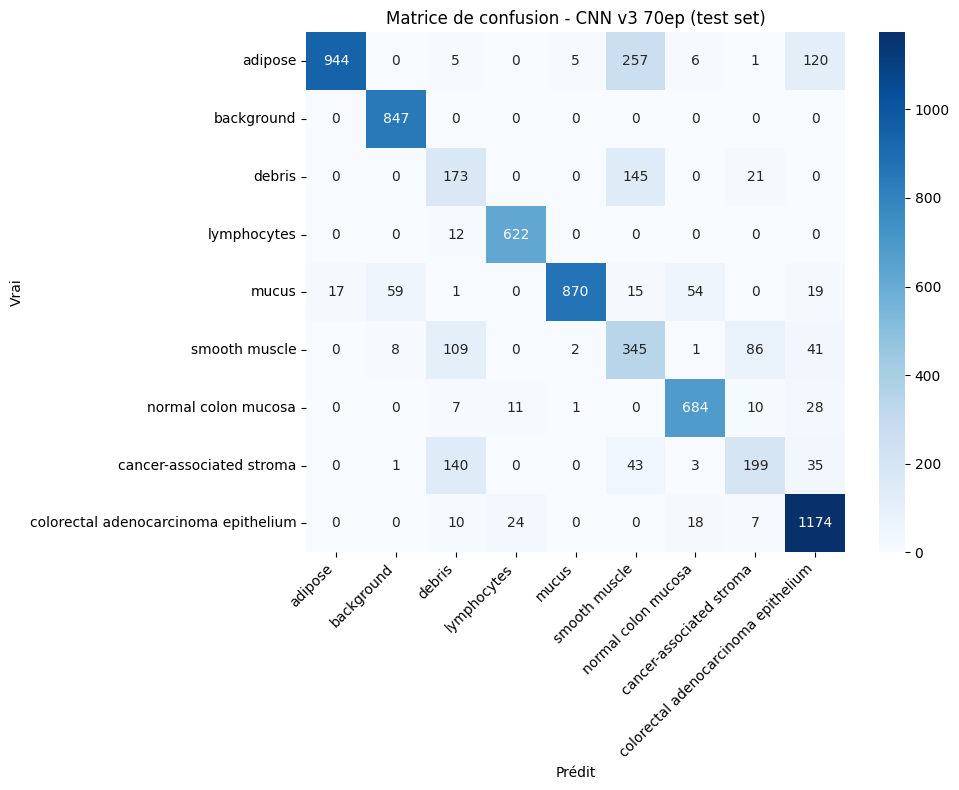


Plus grande confusion : 257 images de 'adipose' classées comme 'smooth muscle'

=== Classification report ===
                                      precision    recall  f1-score   support

                             adipose     0.9823    0.7055    0.8212      1338
                          background     0.9257    1.0000    0.9614       847
                              debris     0.3786    0.5103    0.4347       339
                         lymphocytes     0.9467    0.9811    0.9636       634
                               mucus     0.9909    0.8406    0.9096      1035
                       smooth muscle     0.4286    0.5828    0.4939       592
                 normal colon mucosa     0.8930    0.9231    0.9078       741
            cancer-associated stroma     0.6142    0.4727    0.5342       421
colorectal adenocarcinoma epithelium     0.8285    0.9521    0.8860      1233

                            accuracy                         0.8159      7180
                           ma

In [28]:
print("=== Test + matrice CNN V3 70 époques (extension) ===")
# Test + matrice v3 (70 époques)
cnn_model_v3_70.eval()
test_correct, test_total = 0, 0
all_preds_v3_70, all_labels_v3_70 = [], []
with torch.no_grad():
    for images, labels_batch in test_loader_cnn:
        images = images.to(DEVICE)
        labels_batch = labels_batch.squeeze().long().to(DEVICE)
        outputs = cnn_model_v3_70(images)
        preds = outputs.argmax(1)
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        all_preds_v3_70.extend(preds.cpu().numpy())
        all_labels_v3_70.extend(labels_batch.cpu().numpy())
test_acc_v3_70 = test_correct / test_total
print(f"Test accuracy v3 (70ep) : {test_acc_v3_70:.6f}")

cm_v3_70 = confusion_matrix(all_labels_v3_70, all_preds_v3_70)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_v3_70, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion - CNN v3 70ep (test set)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

cm_v3_70_off = cm_v3_70.copy()
np.fill_diagonal(cm_v3_70_off, 0)
max_idx = np.unravel_index(cm_v3_70_off.argmax(), cm_v3_70_off.shape)
print(f"\nPlus grande confusion : {cm_v3_70_off[max_idx]} images de '{CLASSES[max_idx[0]]}' classées comme '{CLASSES[max_idx[1]]}'")
print("\n=== Classification report ===")
print(classification_report(all_labels_v3_70, all_preds_v3_70, target_names=CLASSES, digits=4))

In [29]:
print("=== Tableau comparatif - toutes les itérations ===")
# Tableau comparatif - toutes les itérations
print("=" * 80)
print("COMPARAISON TOUTES ITÉRATIONS")
print("=" * 80)
print(f"{'Version':<25s} {'Époques':>8s} {'Test acc':>10s} {'Temps':>10s}")
print("-" * 55)
print(f"{'Sans augmentation':<25s} {'40':>8s} {test_accuracy_cnn:>10.6f} {train_time_no_aug:>9.1f}s")
print(f"{'Avec aug (géométrie)':<25s} {'40':>8s} {test_accuracy_cnn_aug:>10.6f} {train_time_aug:>9.1f}s")
print(f"{'v1 (couleur+géométrie)':<25s} {'40':>8s} {test_acc_v1:>10.6f} {train_time_v1:>9.1f}s")
print(f"{'v2 (jitter réduit+blur)':<25s} {'50':>8s} {test_acc_v2:>10.6f} {train_time_v2:>9.1f}s")
print(f"{'v3 (géométrie pure)':<25s} {'50':>8s} {test_acc_v3:>10.6f} {train_time_v3:>9.1f}s")
print(f"{'v3 (géométrie pure)':<25s} {'70':>8s} {test_acc_v3_70:>10.6f} {train_time_v3_70:>9.1f}s")

=== Tableau comparatif - toutes les itérations ===
COMPARAISON TOUTES ITÉRATIONS
Version                    Époques   Test acc      Temps
-------------------------------------------------------
Sans augmentation               40   0.888579     513.8s
Avec aug (géométrie)            40   0.826462     768.5s
v1 (couleur+géométrie)          40   0.917827    1154.3s
v2 (jitter réduit+blur)         50   0.831616    3965.6s
v3 (géométrie pure)             50   0.817688     953.8s
v3 (géométrie pure)             70   0.815877    1385.2s


In [39]:
print("=== Sauvegarde du meilleur modèle CNN ===")
# Sauvegarde du meilleur modèle CNN (v1 = meilleur test accuracy 91.78%)
MODELS_DIR = os.path.join(DATA_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

torch.save(cnn_model_v1.state_dict(), os.path.join(MODELS_DIR, 'NB3_cnn_model_v1.pth'))
torch.save(cnn_model.state_dict(), os.path.join(MODELS_DIR, 'NB3_cnn_model.pth'))

# Sauvegarder tous les historiques
with open(os.path.join(MODELS_DIR, 'NB3_cnn_history_no_aug.pkl'), 'wb') as f:
    pickle.dump(history_cnn_no_aug, f)
with open(os.path.join(MODELS_DIR, 'NB3_cnn_history_aug.pkl'), 'wb') as f:
    pickle.dump(history_cnn_aug, f)
with open(os.path.join(MODELS_DIR, 'NB3_cnn_history_v1.pkl'), 'wb') as f:
    pickle.dump(history_v1, f)
with open(os.path.join(MODELS_DIR, 'NB3_cnn_history_v2.pkl'), 'wb') as f:
    pickle.dump(history_v2, f)
with open(os.path.join(MODELS_DIR, 'NB3_cnn_history_v3.pkl'), 'wb') as f:
    pickle.dump(history_v3, f)
with open(os.path.join(MODELS_DIR, 'NB3_cnn_history_v3_70.pkl'), 'wb') as f:
    pickle.dump(history_v3_70, f)

# Sauvegarder les prédictions du meilleur modèle (v1) pour NB7
with open(os.path.join(MODELS_DIR, 'NB3_cnn_preds.pkl'), 'wb') as f:
    pickle.dump({'all_preds': all_preds_v1, 'all_labels': all_labels_v1}, f)

print("✓ Modèle v1 sauvegardé (NB3_cnn_model_v1.pth)")
print("✓ Modèle sans aug sauvegardé (NB3_cnn_model.pth)")
print("✓ 6 historiques sauvegardés")
print("✓ Prédictions v1 sauvegardées")

=== Sauvegarde du meilleur modèle CNN ===
✓ Modèle v1 sauvegardé (NB3_cnn_model_v1.pth)
✓ Modèle sans aug sauvegardé (NB3_cnn_model.pth)
✓ 6 historiques sauvegardés
✓ Prédictions v1 sauvegardées


---

## Bilan Partie 3 — CNN from scratch

### Tableau récapitulatif

| Version | Epoques | Test acc | Temps | Plus grande confusion |
|---------|---------|----------|-------|----------------------|
| **v1 (couleur + géométrie)** | **40** | **91.78%** | **20.7 min** | Stroma->Muscle (67) |
| Sans aug | 40 | 88.86% | 10.1 min | Adipose->Muscle (132) |
| v2 (jitter réduit + blur) | 50 | 83.16% | 69.1 min | Adipose->Muscle (495) |
| Avec aug (géométrie 40ep) | 40 | 82.65% | 13.6 min | Adipose->Muscle (160) |
| v3 50ep (géométrie pure) | 50 | 81.77% | 16.3 min | Adipose->Muscle (230) |
| v3 70ep (géométrie pure) | 70 | 81.59% | 22.9 min | Adipose->Muscle (257) |

### Ce qu on a appris

1. **Le CNN écrase le MLP** : +21 pts grâce à la structure spatiale
2. **La v1 est le meilleur CNN (91.78%)** : le ColorJitter simule le domain shift
3. **La confusion Cancer/Mucosa du MLP est résolue**
4. **Le stroma reste la classe la plus difficile** (F1 = 0.61-0.66)
5. **L augmentation géométrique seule nuit**
6. **Le GaussianBlur est destructeur à 28x28**
7. **Plus d époques ne signifie pas meilleur test**

### Nb paramètres (Q3.3)

- 1ère couche conv : (3x3x3 + 1) x 32 = **896 paramètres**
- Total : **436 649 paramètres**

### Analyses clés

**Le CNN from scratch bat le ResNet pré-entraîné :**
Notre CNN v1, avec seulement 436 649 paramètres entraînés from scratch, atteint 91.78% de test accuracy. C est mieux que le ResNet-18 frozen ((voir partie 4)), un modèle 25 fois plus gros (11.1M paramètres) pré-entraîné sur 1.2 million d images ImageNet. Comment est-ce possible ? Le ColorJitter (variation de luminosité et contraste de 10%) simule exactement ce que le domain shift produit entre les deux hôpitaux : des différences de coloration H&E. En entraînant le CNN à être robuste à ces variations, on le prépare à affronter les images d un hôpital qu il n a jamais vu. Le ResNet frozen, lui, utilise des features ImageNet figées qui ne s adaptent pas à ces variations.

**Pourquoi le CNN résout la confusion Cancer/Mucosa mais pas Stroma/Muscle :**
Le MLP confondait massivement Mucosa et Cancer (259 erreurs) car il ne voyait que les couleurs, et les deux classes partagent des tons violets similaires. Le CNN résout cette confusion car ses filtres convolutifs captent la texture globale : l organisation cellulaire ordonnée de la muqueuse normale vs la prolifération anarchique du cancer. En revanche, le CNN échoue encore sur Stroma vs Smooth Muscle (F1 stroma = 0.66). La raison est différente : ces deux tissus conjonctifs se distinguent par l organisation fine de leurs fibres (parallèles pour le muscle, désordonnées pour le stroma). Or à 28x28 pixels, cette distinction est trop fine pour être captée par des filtres 3x3. C est une limite du dataset (résolution trop basse), pas de l architecture CNN.

**Le domain shift quantifié :**
L écart entre val (99%) et test (88.86%) est de 10 points. Cet écart représente le coût du domain shift : le modèle est quasi parfait sur les données de l hôpital A (même distribution que le train) mais perd 10 points sur l hôpital B (distribution différente : coloration, scanner, protocole de préparation). La v1 avec ColorJitter réduit indirectement cet écart en entraînant le modèle à tolérer des variations de couleur, ce qui le rend plus robuste aux différences inter-hôpitaux.

**Le paradoxe des époques :**
On observe que plus d époques améliore la val accuracy mais dégrade le test accuracy. La v3 à 70 époques a la meilleure val de toutes les itérations (99.4%) mais le pire test (81.59%). C est la définition empirique du surapprentissage sur un domaine spécifique : le modèle apprend de mieux en mieux les spécificités de l hôpital A (coloration particulière, artefacts, types de backgrounds) mais ces spécificités n existent pas dans l hôpital B. Chaque époque supplémentaire renforce cette mémorisation au détriment de la capacité à généraliser.

### Limites méthodologiques

- **Une seule seed (42)** : les résultats sont reproductibles mais pas testés pour leur robustesse. En recherche, on ferait tourner 3-5 seeds et on reporterait mean +/- std
- **Test set utilisé pour la sélection** : le choix du meilleur modèle (v1) a été fait sur le test accuracy. En production, on choisirait sur le val et on ne regarderait le test qu une seule fois
- **Pas de plan factoriel** : la v1 change géométrie et couleur simultanément. Pour isoler l effet du ColorJitter, il faudrait une version couleur seule

---





In [40]:
print("=== Temps total ===")
# Temps total
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")

=== Temps total ===
Temps total du notebook : 10678.5s (178.0 min)
